# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,precision_score
import re
import string
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [3]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Projects\NLP\Mental-Health-Twitter.csv")
df

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,A day without sunshine is like night.,1169875706,442,230,7,1063601,0,0
19996,19996,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,"Boren's Laws: (1) When in charge, ponder. (2) ...",1169875706,442,230,7,1063601,0,0
19997,19997,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,The flow chart is a most thoroughly oversold p...,1169875706,442,230,7,1063601,0,0
19998,19998,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,"Ships are safe in harbor, but they were never ...",1169875706,442,230,7,1063601,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB


In [5]:
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [6]:
df.tail()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
19995,19995,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,A day without sunshine is like night.,1169875706,442,230,7,1063601,0,0
19996,19996,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,"Boren's Laws: (1) When in charge, ponder. (2) ...",1169875706,442,230,7,1063601,0,0
19997,19997,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,The flow chart is a most thoroughly oversold p...,1169875706,442,230,7,1063601,0,0
19998,19998,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,"Ships are safe in harbor, but they were never ...",1169875706,442,230,7,1063601,0,0
19999,19999,819334270825197568,Thu Jan 12 00:04:47 +0000 2017,Black holes are where God is dividing by zero.,1169875706,442,230,7,1063601,0,0


In [7]:
df.columns

Index(['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id',
       'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label'],
      dtype='object')

In [8]:
df.shape

(20000, 11)

In [9]:
df.isnull().sum()

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

In [10]:
df=df.drop(['Unnamed: 0', 'post_id', 'post_created',  'user_id',
       'followers', 'friends', 'favourites', 'statuses', 'retweets'],axis=1)
df

,post_text,label
0,It's just over 2 years since I was diagnosed w...,1
1,"It's Sunday, I need a break, so I'm planning t...",1
2,Awake but tired. I need to sleep but my brain ...,1
3,RT @SewHQ: #Retro bears make perfect gifts and...,1
4,It’s hard to say whether packing lists are mak...,1
...,...,...
19995,A day without sunshine is like night.,0
19996,"Boren's Laws: (1) When in charge, ponder. (2) ...",0
19997,The flow chart is a most thoroughly oversold p...,0
19998,"Ships are safe in harbor, but they were never ...",0


In [11]:
df=df.sample(frac=1)
#sample(frac=1) used for shuffling the dataset
#otherwise it will be biased during splitting train test
df

,post_text,label
9314,I think its a SwaggaBoyLos type morning.yeahhh...,1
113,RT @Elephantopia: ELEPHANT FACT OF THE DAY: An...,1
1762,Circle's End: Depression Therapy — Who had a g...,1
15930,Tak sure her friend tu ke or one of her acquai...,0
13066,Why Trump voters are not welcome in my house t...,0
...,...,...
17185,RT @NarcisaSajili: @YongstersClub @YONGPILIPIN...,0
6953,"The Anxiety & Phobia Workbook, Fourth Edition ...",1
11129,wow i cant stop watching my lrt,0
5833,...other spots. Just be careful.,1


In [12]:
df.reset_index(inplace=True)
df.drop(['index'],axis=1,inplace=True)
df

,post_text,label
0,I think its a SwaggaBoyLos type morning.yeahhh...,1
1,RT @Elephantopia: ELEPHANT FACT OF THE DAY: An...,1
2,Circle's End: Depression Therapy — Who had a g...,1
3,Tak sure her friend tu ke or one of her acquai...,0
4,Why Trump voters are not welcome in my house t...,0
...,...,...
19995,RT @NarcisaSajili: @YongstersClub @YONGPILIPIN...,0
19996,"The Anxiety & Phobia Workbook, Fourth Edition ...",1
19997,wow i cant stop watching my lrt,0
19998,...other spots. Just be careful.,1


In [13]:
df.rename(columns={"post_text":"text"},inplace=True)

In [14]:
df

,text,label
0,I think its a SwaggaBoyLos type morning.yeahhh...,1
1,RT @Elephantopia: ELEPHANT FACT OF THE DAY: An...,1
2,Circle's End: Depression Therapy — Who had a g...,1
3,Tak sure her friend tu ke or one of her acquai...,0
4,Why Trump voters are not welcome in my house t...,0
...,...,...
19995,RT @NarcisaSajili: @YongstersClub @YONGPILIPIN...,0
19996,"The Anxiety & Phobia Workbook, Fourth Edition ...",1
19997,wow i cant stop watching my lrt,0
19998,...other spots. Just be careful.,1


# Preprocessing Text Data

In [16]:
def wordopt(text): #creating function to process text
    text=text.lower()
    text=re.sub('\[.*?\]','',text)
    text=re.sub("\\W"," ",text)
    text=re.sub('https?://\S+|www\.\S+','',text)
    text=re.sub('<.*?>+','',text)
    text=re.sub('[%s]'% re.escape(string.punctuation),'',text)
    text=re.sub('\n','',text)
    text=re.sub('\w*\d\w*','',text)
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
C:\Users\HP\AppData\Local\Temp\ipykernel_11552\1462576528.py:3: SyntaxWarning: invalid escape sequence '\['
  text=re.sub('\[.*?\]','',text)
C:\Users\HP\AppData\Local\Temp\ipykernel_11552\1462576528.py:5: SyntaxWarning: invalid escape sequence '\S'
  text=re.sub('https?://\S+|www\.\S+','',text)
C:\Users\HP\AppData\Local\Temp\ipykernel_11552\1462576528.py:9: SyntaxWarning: invalid escape sequence '\w'
  text=re.sub('\w*\d\w*','',text)


In [17]:
df["text"]=df["text"].apply(wordopt)
df

,text,label
0,i think its a swaggaboylos type morning yeahhh...,1
1,rt elephantopia elephant fact of the day an...,1
2,circle s end depression therapy who had a g...,1
3,tak sure her friend tu ke or one of her acquai...,0
4,why trump voters are not welcome in my house t...,0
...,...,...
19995,rt narcisasajili yongstersclub yongpilipin...,0
19996,the anxiety phobia workbook fourth edition ...,1
19997,wow i cant stop watching my lrt,0
19998,other spots just be careful,1


# Data Visualization

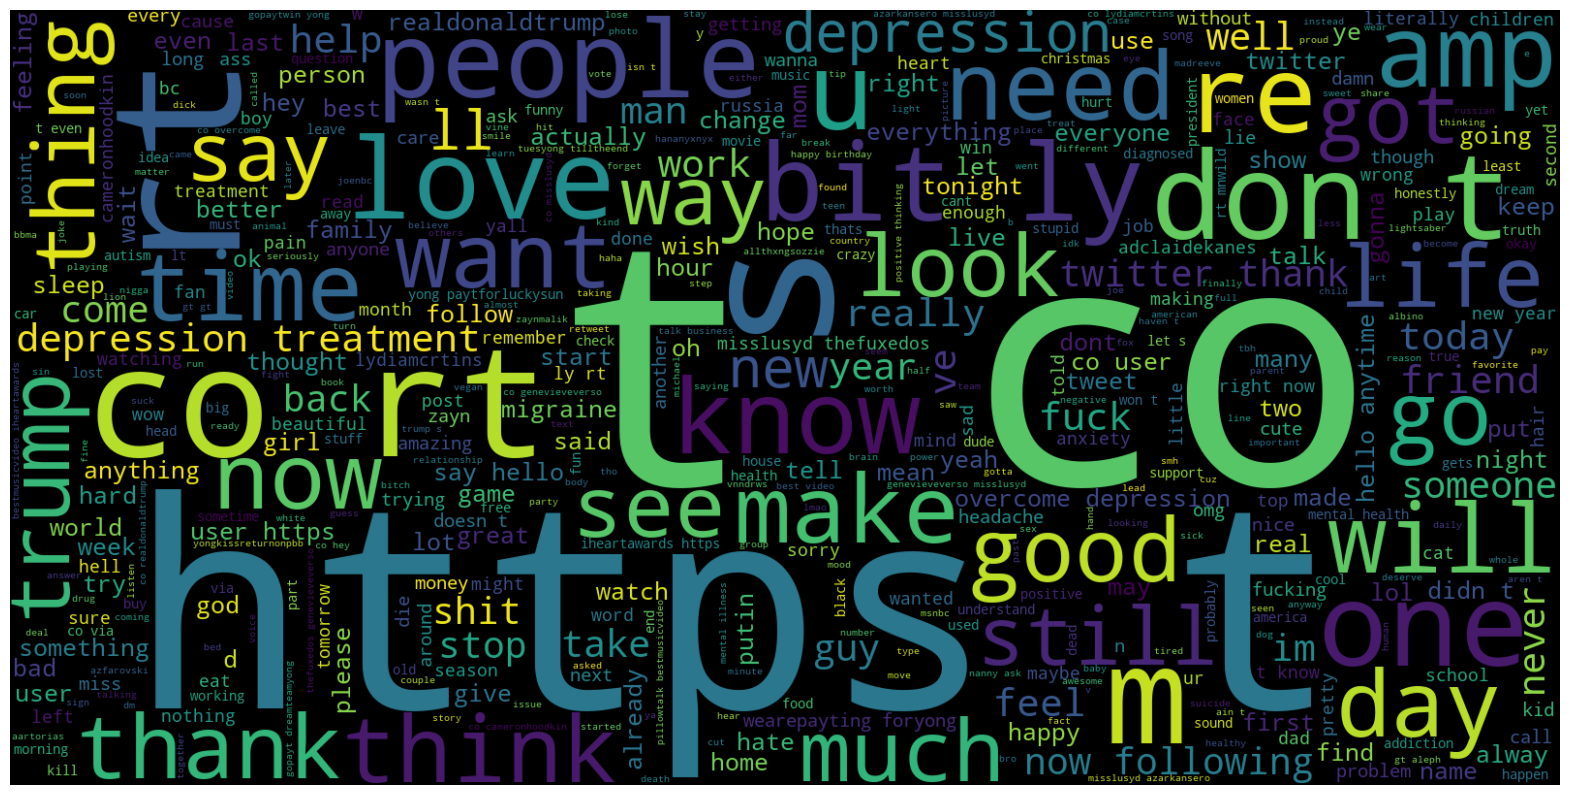

In [19]:
text=' '.join([word for word in df['text']])
plt.figure(figsize=(20,15),facecolor='None')
wordcloud=WordCloud(max_words=500,width=1600,height=800).generate(text)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

# Data Splitting

In [21]:
x=df['text']
y=df['label']
print(x)
print(y)

0        i think its a swaggaboylos type morning yeahhh...
1        rt  elephantopia  elephant fact of the day  an...
2        circle s end  depression therapy   who had a g...
3        tak sure her friend tu ke or one of her acquai...
4        why trump voters are not welcome in my house t...
                               ...                        
19995    rt  narcisasajili   yongstersclub  yongpilipin...
19996    the anxiety   phobia workbook  fourth edition ...
19997                      wow i cant stop watching my lrt
19998                        other spots  just be careful 
19999                                            farewell 
Name: text, Length: 20000, dtype: object
0        1
1        1
2        1
3        0
4        0
        ..
19995    0
19996    1
19997    0
19998    1
19999    0
Name: label, Length: 20000, dtype: int64


In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [23]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(15000,) (5000,) (15000,) (5000,)


# NLP

In [25]:
vectorization=TfidfVectorizer()
xv_train=vectorization.fit_transform(x_train) #train-fit
xv_test=vectorization.transform(x_test)#test-transform

In [26]:
xv_train

<15000x20420 sparse matrix of type '<class 'numpy.float64'>'
	with 171882 stored elements in Compressed Sparse Row format>

In [27]:
xv_train.shape

(15000, 20420)

In [28]:
xv_test.shape

(5000, 20420)

# Model Building Algorithms

# Logistic Regression

In [31]:
LR=LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [32]:
pred_lr1=LR.predict(xv_test)
pred_lr1

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [33]:
# model validation checking
from sklearn.metrics import accuracy_score

In [34]:
print(accuracy_score(y_test,pred_lr1))

0.8488


# Naive Bayes Theorem

# MultinomialNB

In [37]:
from sklearn.naive_bayes import MultinomialNB
MNB = MultinomialNB()
MNB.fit(xv_train,y_train)
predict1 = MNB.predict(xv_test)
predict1

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [38]:
print(accuracy_score(y_test,predict1))

0.8706


# BernoulliNB

In [40]:
from sklearn.naive_bayes import BernoulliNB
BNB = BernoulliNB()
BNB.fit(xv_train,y_train)
predict3 = BNB.predict(xv_test)
predict3

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

In [41]:
print(accuracy_score(y_test,predict3))

0.8724


# Random Forest

In [43]:
RF= RandomForestClassifier(random_state=42)
RF_model=RF.fit(xv_train,y_train)


In [44]:
y_pred_RF1=RF_model.predict(xv_test)
y_pred_RF1

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [45]:
#model validation checking
print(accuracy_score(y_test,y_pred_RF1))

0.823


SVM

In [47]:
from sklearn.svm import SVC

In [48]:
SVM=SVC(kernel='rbf')
svm_clf= SVC(random_state=42)
svm_model=svm_clf.fit(xv_train,y_train)

In [49]:
y_pred_svm1=svm_model.predict(xv_test)
y_pred_svm1

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [50]:
print(accuracy_score(y_test,y_pred_svm1))

0.8636


KNN

In [52]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()
from sklearn.metrics import accuracy_score
metric_k= []
#empty list for appending accuracy of model for each k values
neighbors = np.arange(3, 15)
#k value from 3 to 14

for k in neighbors:
    knn=KNeighborsClassifier(n_neighbors=k)
    model=knn.fit(xv_train,y_train)
    y_pred_knn=model.predict(xv_test)
    acc=accuracy_score(y_test,y_pred_knn)
    metric_k.append(acc)

In [53]:
metric_k

[0.7844,
 0.7734,
 0.7984,
 0.7998,
 0.8074,
 0.8028,
 0.8088,
 0.8096,
 0.8134,
 0.816,
 0.8116,
 0.809]

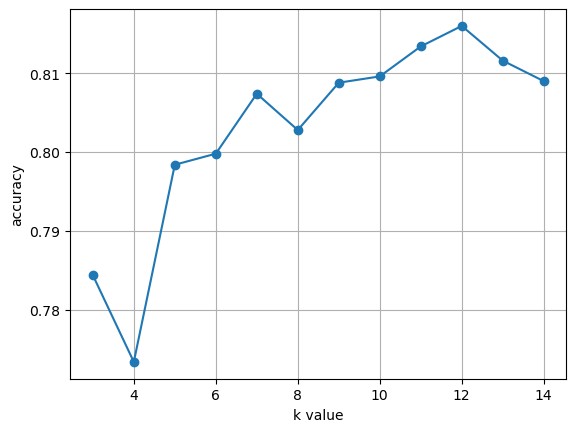

In [54]:
plt.plot(neighbors,metric_k,'o-')
#plotting the accuracy for each k value
plt.xlabel('k value')
plt.ylabel('accuracy')
plt.grid()

In [55]:
#accuracy is more for k=8,so creating model using k=8
#knn=KNeighborsClassifier(n_neighbors=8)
#model=knn.fit(xv_train,y_train)
#y_pred_knn=model.predict(xv_test)

In [56]:
#print(accuracy_score(y_test,y_pred_knn))

In [57]:
y_pred_knn1=model.predict(xv_test)
y_pred_knn1

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [58]:
print(accuracy_score(y_test,y_pred_knn1))

0.809


Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
DT= DecisionTreeClassifier(random_state=42)

In [62]:
dt_model=DT.fit(xv_train,y_train)

In [63]:
y_pred_dt1=dt_model.predict(xv_test)
y_pred_dt1

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [64]:
print(accuracy_score(y_test,y_pred_dt1))

0.7932


Boosting

In [66]:
from sklearn.ensemble import AdaBoostClassifier
AB= AdaBoostClassifier()
AB.fit(xv_train,y_train)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier()

In [67]:
ypred_ada1= AB.predict(xv_test)
ypred_ada1

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [68]:
print(accuracy_score(y_test,ypred_ada1))

0.7674


In [70]:
#pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   - -------------------------------------- 6.0/150.0 MB 36.7 MB/s eta 0:00:04
   ---- ----------------------------------- 17.0/150.0 MB 44.7 MB/s eta 0:00:03
   ------ --------------------------------- 26.0/150.0 MB 42.1 MB/s eta 0:00:03
   -------- ------------------------------- 30.7/150.0 MB 37.4 MB/s eta 0:00:04
   -------- ------------------------------- 32.8/150.0 MB 32.0 MB/s eta 0:00:04
   -------- ------------------------------- 33.0/150.0 MB 30.0 MB/s eta 0:00:04
   -------- ------------------------------- 33.6/150.0 MB 23.2 MB/s eta 0:00:06
   --------- ------------------------------ 33.8/150.0 MB 20.8 MB/s eta 0:00:06
   --------- ------------------------------ 34.3/150.0 MB 18.3 MB/s eta 0:00:07
   --------- ------------------------------ 34.9/150.0 MB 16.7 MB/s eta 0:00:07
   --------- ------------------------------ 35.1/150.0 MB 16.1 MB/s eta 0:00:08
   --------- ------------------------------ 35.1/1

In [72]:
from xgboost import XGBClassifier
XGB = XGBClassifier()
XGB.fit(xv_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [73]:
ypred_xgb1 = XGB.predict(xv_test)
ypred_xgb1

array([0, 0, 1, ..., 0, 0, 0])

In [74]:
print(accuracy_score(y_test,ypred_xgb1))

0.8184


In [75]:
from sklearn.ensemble import GradientBoostingClassifier
GB= GradientBoostingClassifier()
GB.fit(xv_train,y_train)

GradientBoostingClassifier()

In [76]:
ypred_gra1 = GB.predict(xv_test)
ypred_gra1


array([0, 0, 1, ..., 0, 1, 1], dtype=int64)

In [77]:
print(accuracy_score(y_test,ypred_gra1))

0.7772


In [78]:
pt=[]
for i in[LR,MNB,BNB,RF,SVM,KNN,DT,AB,XGB,GB]:
    i.fit(xv_train,y_train)
    pt.append(round(accuracy_score(y_test,i.predict(xv_test))*100,2))
print(pt)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[84.88, 87.06, 87.24, 82.3, 86.36, 79.84, 79.32, 76.76, 81.84, 77.74]


In [79]:
pd.set_option('display.max_colwidth', None)  # Show full content of cells

In [80]:
x.head()

0                                                    i think its a swaggaboylos type morning yeahhh bout to bump the crown aint safe   iamkinglos
1    rt  elephantopia  elephant fact of the day  an elephant herd is considered one of the most closely knit societies of any animal     http    
2                                                      circle s end  depression therapy   who had a great winter  mental health      http   t co 
3                      tak sure her friend tu ke or one of her acquaintances there in university      girl tu  parents dia pun duduk new zealand 
4                                                                         why trump voters are not welcome in my house this holiday https   t co 
Name: text, dtype: object

In [81]:
y.head()

0    1
1    1
2    1
3    0
4    0
Name: label, dtype: int64

In [82]:
# Example text
example = ['''branchlord  ennuist  unknownoddity  gradingus  nuen  ssmangos are you    ''']
# Transform the example text
example_vectorized = vectorization.transform(example)
#Make predictions on the example data
result = BNB.predict(example_vectorized)

print(result)
if(result==0):
    print("Negative review")
else:
    print("positive review")

[1]
positive review


In [83]:
# Example text
example = ['''i hate it when my apple watch tells me to stand up    i can t really do that sitting in la traffic   ''']
# Transform the example text
example_vectorized = vectorization.transform(example)
#Make predictions on the example data
result = MNB.predict(example_vectorized)

print(result)
# if(result==0):
#     print("Negative review")
# else:
#     print("positive review")

[1]
